# Minería de Datos - Semana 8
# Ejercicio Integrador: Aprendizaje Supervisado

## Objetivo del trabajo

En este trabajo se desarrolla el ejercicio integrador de la Clase 8 de Minería de Datos.

El caso plantea una empresa de seguros que necesita construir dos modelos:

1. **Regresión Logística** para predecir si un cliente presentará un reclamo: Sí o No.
2. **Regresión Múltiple** para estimar el monto del reclamo en dólares.

También se realiza una interacción con una herramienta de IA y una reflexión final sobre los resultados.

# 1. Importación de librerías

Se importan las librerías necesarias para trabajar con datos, entrenar modelos y evaluar resultados.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


# 2. Creación del dataset

El ejercicio propone un dataset pequeño de una empresa de seguros.

Las variables son:

- `Cliente`: identificador del cliente.
- `Edad`: edad del cliente.
- `Ingresos`: ingresos del cliente en dólares.
- `Historial_Accidentes`: indica si tuvo accidentes previos.
- `Monto_Reclamo`: monto del reclamo en dólares.
- `Reclamo`: indica si el cliente realizó un reclamo o no.

In [2]:
data = {
    "Cliente": [1, 2, 3, 4, 5, 6],
    "Edad": [25, 40, 32, 50, 28, 45],
    "Ingresos": [30000, 55000, 42000, 60000, 37000, 52000],
    "Historial_Accidentes": [1, 0, 1, 0, 1, 0],
    "Monto_Reclamo": [5000, 0, 7500, 0, 6500, 0],
    "Reclamo": ["Sí", "No", "Sí", "No", "Sí", "No"]
}

df = pd.DataFrame(data)
df

,Cliente,Edad,Ingresos,Historial_Accidentes,Monto_Reclamo,Reclamo
0,1,25,30000,1,5000,Sí
1,2,40,55000,0,0,No
2,3,32,42000,1,7500,Sí
3,4,50,60000,0,0,No
4,5,28,37000,1,6500,Sí
5,6,45,52000,0,0,No


# 3. Exploración inicial

Antes de entrenar modelos, se revisa el dataset para conocer su estructura, tipos de datos y valores nulos.

In [3]:
print("Filas y columnas:", df.shape)

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())

df.head()

Filas y columnas: (6, 6)

Tipos de datos:
Cliente                  int64
Edad                     int64
Ingresos                 int64
Historial_Accidentes     int64
Monto_Reclamo            int64
Reclamo                 object
dtype: object

Valores nulos:
Cliente                 0
Edad                    0
Ingresos                0
Historial_Accidentes    0
Monto_Reclamo           0
Reclamo                 0
dtype: int64


,Cliente,Edad,Ingresos,Historial_Accidentes,Monto_Reclamo,Reclamo
0,1,25,30000,1,5000,Sí
1,2,40,55000,0,0,No
2,3,32,42000,1,7500,Sí
3,4,50,60000,0,0,No
4,5,28,37000,1,6500,Sí


# 4. Preprocesamiento

El ejercicio pide convertir la variable `Reclamo` a numérica:

- `No = 0`
- `Sí = 1`

Esto es necesario porque los modelos trabajan con datos numéricos.

In [4]:
df["Reclamo_Num"] = df["Reclamo"].map({"No": 0, "Sí": 1})
df

,Cliente,Edad,Ingresos,Historial_Accidentes,Monto_Reclamo,Reclamo,Reclamo_Num
0,1,25,30000,1,5000,Sí,1
1,2,40,55000,0,0,No,0
2,3,32,42000,1,7500,Sí,1
3,4,50,60000,0,0,No,0
4,5,28,37000,1,6500,Sí,1
5,6,45,52000,0,0,No,0


# 5. Variables predictoras y variables objetivo

Las variables predictoras son:

- `Edad`
- `Ingresos`
- `Historial_Accidentes`

Para la **Regresión Logística**, la variable objetivo es `Reclamo_Num`.

Para la **Regresión Múltiple**, la variable objetivo es `Monto_Reclamo`.

In [5]:
X = df[["Edad", "Ingresos", "Historial_Accidentes"]]

y_clasificacion = df["Reclamo_Num"]
y_regresion = df["Monto_Reclamo"]

display(X)
display(y_clasificacion)
display(y_regresion)

,Edad,Ingresos,Historial_Accidentes
0,25,30000,1
1,40,55000,0
2,32,42000,1
3,50,60000,0
4,28,37000,1
5,45,52000,0


0    1
1    0
2    1
3    0
4    1
5    0
Name: Reclamo_Num, dtype: int64

0    5000
1       0
2    7500
3       0
4    6500
5       0
Name: Monto_Reclamo, dtype: int64

# 6. División en entrenamiento y prueba

Se divide el dataset en entrenamiento y prueba.

El ejercicio pide una división aproximada de 80% entrenamiento y 20% prueba.

Como el dataset es muy pequeño, los resultados deben interpretarse con cuidado.

In [6]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X,
    y_clasificacion,
    test_size=0.2,
    random_state=42,
    stratify=y_clasificacion
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X,
    y_regresion,
    test_size=0.2,
    random_state=42
)

print("Entrenamiento clasificación:", X_train_c.shape)
print("Prueba clasificación:", X_test_c.shape)
print("Entrenamiento regresión:", X_train_r.shape)
print("Prueba regresión:", X_test_r.shape)

Entrenamiento clasificación: (4, 3)
Prueba clasificación: (2, 3)
Entrenamiento regresión: (4, 3)
Prueba regresión: (2, 3)


# 7. Regresión Logística

La Regresión Logística se utiliza para clasificación.

En este caso sirve para predecir si un cliente hará o no un reclamo.

In [7]:
modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(X_train_c, y_train_c)

y_pred_c = modelo_logistico.predict(X_test_c)

print("Predicciones:", y_pred_c)
print("Valores reales:", y_test_c.values)

Predicciones: [1 0]
Valores reales: [1 0]


# 8. Evaluación de la Regresión Logística

Se evalúa el modelo con:

- precisión,
- matriz de confusión,
- reporte de clasificación.

In [8]:
precision = accuracy_score(y_test_c, y_pred_c)
matriz = confusion_matrix(y_test_c, y_pred_c)

print("Precisión:", precision)

print("\nMatriz de confusión:")
print(matriz)

print("\nReporte de clasificación:")
print(classification_report(y_test_c, y_pred_c, zero_division=0))

Precisión: 1.0

Matriz de confusión:
[[1 0]
 [0 1]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



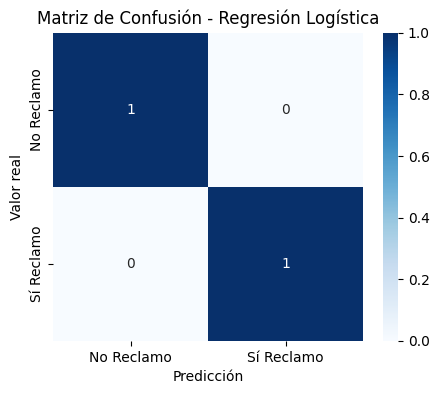

In [9]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Reclamo", "Sí Reclamo"],
    yticklabels=["No Reclamo", "Sí Reclamo"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

# 9. Interpretación de la Regresión Logística

El modelo intenta predecir si un cliente realizará o no un reclamo.

En este dataset, el `Historial_Accidentes` parece ser una variable importante, porque los clientes con accidentes previos están asociados a reclamos.

De todas formas, el dataset es muy pequeño. Por eso, los resultados sirven como práctica, pero no deberían generalizarse sin más datos.

# 10. Regresión Múltiple

La Regresión Múltiple se utiliza para predecir valores numéricos continuos.

En este caso se utiliza para estimar el monto del reclamo en dólares.

In [10]:
modelo_regresion = LinearRegression()

modelo_regresion.fit(X_train_r, y_train_r)

y_pred_r = modelo_regresion.predict(X_test_r)

print("Predicciones del monto del reclamo:")
print(y_pred_r)

print("\nValores reales:")
print(y_test_r.values)

Predicciones del monto del reclamo:
[ 8071.42857143 -7857.14285714]

Valores reales:
[5000    0]


# 11. Evaluación de la Regresión Múltiple

Se evalúa el modelo con:

- `R²`: mide cuánto explica el modelo.
- `MSE`: error cuadrático medio.
- `MAE`: error absoluto medio.

Mientras más bajo sea MSE y MAE, mejor.  
En R², mientras más cercano a 1, mejor.

In [11]:
r2 = r2_score(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)

print(f"R²: {r2:.2f}")
print(f"MSE: {mse:.2f}")
print(f"MAE: {mae:.2f}")

R²: -4.69
MSE: 35584183.67
MAE: 5464.29


In [12]:
comparacion_regresion = pd.DataFrame({
    "Valor real": y_test_r.values,
    "Valor predicho": y_pred_r
})

comparacion_regresion

,Valor real,Valor predicho
0,5000,8071.428571
1,0,-7857.142857


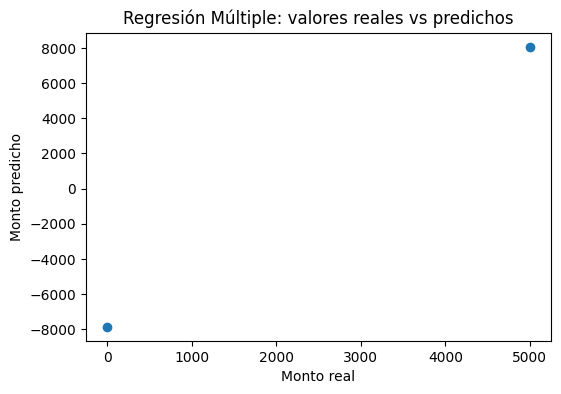

In [13]:
plt.figure(figsize=(6, 4))

plt.scatter(y_test_r, y_pred_r)

plt.xlabel("Monto real")
plt.ylabel("Monto predicho")
plt.title("Regresión Múltiple: valores reales vs predichos")

plt.show()

# 12. Coeficientes de la Regresión Múltiple

Los coeficientes muestran cómo influye cada variable en la predicción del monto del reclamo.

Un coeficiente positivo indica que, cuando esa variable aumenta, el monto estimado tiende a aumentar.  
Un coeficiente negativo indica que, cuando esa variable aumenta, el monto estimado tiende a disminuir.

In [14]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo_regresion.coef_
})

coeficientes

,Variable,Coeficiente
0,Edad,1142.857143
1,Ingresos,-0.714286
2,Historial_Accidentes,15214.285714


# 13. Comparación entre ambos modelos

En este trabajo se aplicaron dos modelos distintos porque responden preguntas diferentes.

## Regresión Logística

Sirve para responder:

**¿El cliente realizará un reclamo?**

La respuesta es una categoría: Sí o No.

## Regresión Múltiple

Sirve para responder:

**¿Cuál será el monto del reclamo?**

La respuesta es un valor numérico.

In [15]:
resumen_modelos = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Regresión Múltiple"],
    "Objetivo": [
        "Predecir si hay reclamo",
        "Estimar monto del reclamo"
    ],
    "Variable objetivo": [
        "Reclamo_Num",
        "Monto_Reclamo"
    ],
    "Métrica principal": [
        "Precisión y matriz de confusión",
        "R², MSE y MAE"
    ]
})

resumen_modelos

,Modelo,Objetivo,Variable objetivo,Métrica principal
0,Regresión Logística,Predecir si hay reclamo,Reclamo_Num,Precisión y matriz de confusión
1,Regresión Múltiple,Estimar monto del reclamo,Monto_Reclamo,"R², MSE y MAE"


# 14. Interacción con una herramienta de IA

## Consulta realizada

> Tengo un dataset de aseguradoras. ¿Qué estrategias de modelado recomendarías para predecir el monto de un reclamo?

## Respuesta resumida de la IA

Una herramienta de IA recomendaría:

- revisar y limpiar los datos,
- analizar variables como edad, ingresos e historial de accidentes,
- usar modelos de regresión para predecir montos,
- evaluar el modelo con MAE, MSE y R²,
- comparar distintos modelos,
- revisar posibles valores atípicos.

## Reflexión

La respuesta es útil porque coincide con lo trabajado en clase.

Sin embargo, la IA no reemplaza la interpretación del estudiante. Es necesario entender las métricas y revisar si el resultado tiene sentido.

# 15. Reflexión final

En este ejercicio se aplicaron dos técnicas de aprendizaje supervisado.

La **Regresión Logística** permitió trabajar con un problema de clasificación, ya que se buscaba predecir si el cliente presentaría o no un reclamo.

La **Regresión Múltiple** permitió trabajar con un problema de regresión, ya que se buscaba estimar el monto del reclamo.

La elección del modelo depende del tipo de variable que se quiere predecir:

- si la respuesta es una categoría, corresponde usar clasificación;
- si la respuesta es un número continuo, corresponde usar regresión.

También se observa que el tamaño del dataset influye mucho en los resultados. Al trabajar con pocos datos, las métricas pueden ser inestables. Por eso sería conveniente contar con más registros para obtener modelos más confiables.

# 16. Conclusión general

El ejercicio permitió aplicar conceptos centrales del aprendizaje supervisado.

Se construyó un modelo de Regresión Logística para clasificar clientes según la posibilidad de reclamo y un modelo de Regresión Múltiple para estimar el monto del reclamo.

Además, se evaluaron ambos modelos con métricas adecuadas para cada caso.

Como conclusión, el aprendizaje supervisado permite usar datos históricos para realizar predicciones, siempre teniendo en cuenta la calidad y cantidad de los datos disponibles.